In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:\projects\medical insurance cost prediction\dataset\insurance.csv")
df.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\SOHAM\AppData\Local\Temp\ipykernel_17264\1827637966.py:1: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv("D:\projects\medical insurance cost prediction\dataset\insurance.csv")


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.drop_duplicates(inplace=True)

Feature Engineering


In [8]:
df['Weight_Condition'] = np.where(df['bmi'] < 18.00, 'Underweight', 
                                  np.where((df['bmi'] >= 18.00) & (df['bmi'] <= 25.00), 'Normal Weight',
                                  np.where((df['bmi'] > 25.00) & (df['bmi'] < 30.00), 'Overweight', 
                                  'Obese')))

In [9]:
df

,age,sex,bmi,children,smoker,region,charges,Weight_Condition
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal Weight
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


In [10]:
df["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [11]:
df.groupby(["sex"])['smoker'].value_counts()

sex     smoker
female  no        547
        yes       115
male    no        516
        yes       159
Name: count, dtype: int64

<Axes: xlabel='smoker', ylabel='count'>

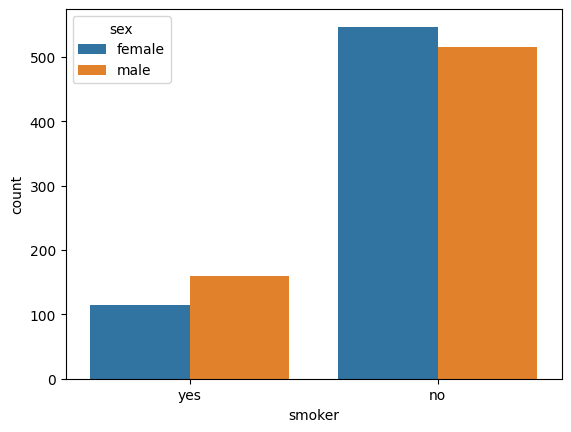

In [12]:
sns.countplot(data=df,x="smoker",hue="sex",stat='count')

In [13]:
df['Weight_Condition'].value_counts()

Weight_Condition
Obese            706
Overweight       384
Normal Weight    232
Underweight       15
Name: count, dtype: int64

<Axes: xlabel='Weight_Condition', ylabel='count'>

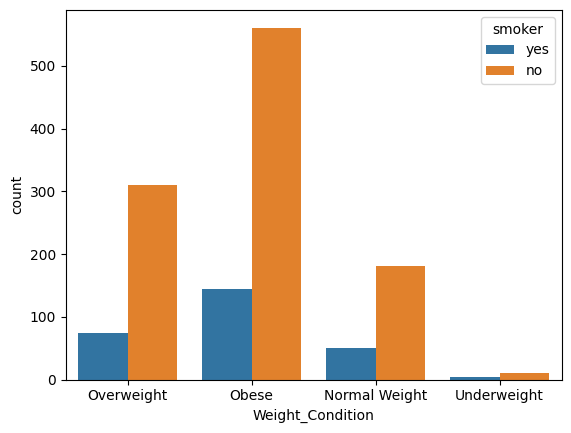

In [14]:
sns.countplot(data=df, x='Weight_Condition', hue='smoker')

In [15]:
df.groupby(["region"])['smoker'].value_counts()

region     smoker
northeast  no        257
           yes        67
northwest  no        266
           yes        58
southeast  no        273
           yes        91
southwest  no        267
           yes        58
Name: count, dtype: int64

<Axes: xlabel='region', ylabel='charges'>

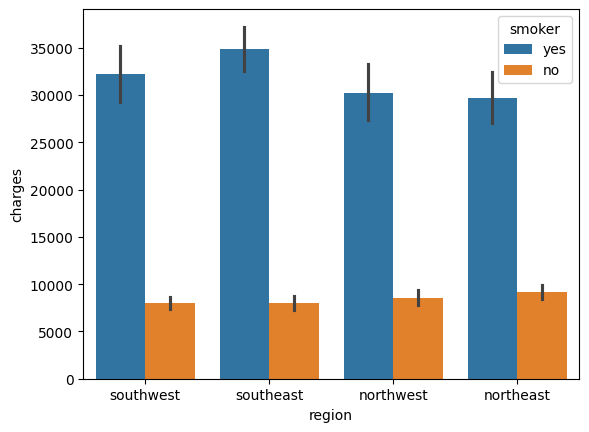

In [16]:
sns.barplot(data=df, x='region', y='charges', hue='smoker')

In [17]:
smoker_status = df.groupby(['Weight_Condition', 'smoker']).agg({'charges' : 'count'}).reset_index()
smoker_status.columns = ('Weight_Condition', 'smoker', 'count')
smoker_status

,Weight_Condition,smoker,count
0,Normal Weight,no,181
1,Normal Weight,yes,51
2,Obese,no,561
3,Obese,yes,145
4,Overweight,no,310
5,Overweight,yes,74
6,Underweight,no,11
7,Underweight,yes,4


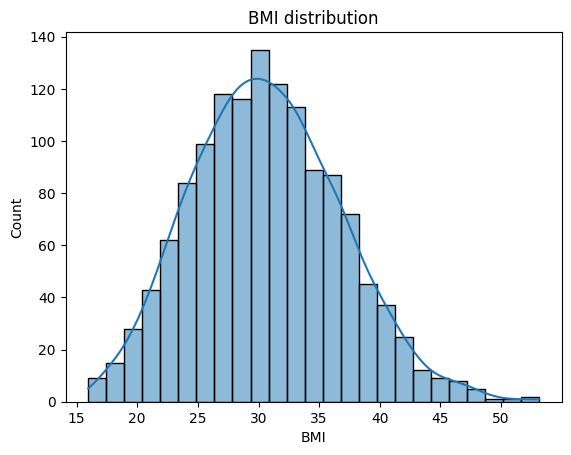

In [18]:
sns.histplot(data=df, x="bmi",kde=True)
plt.title("BMI distribution")
plt.xlabel("BMI")
plt.show()

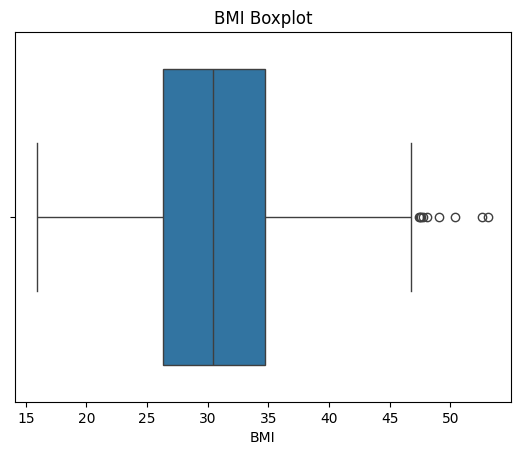

In [19]:
sns.boxplot(data=df, x="bmi")
plt.title("BMI Boxplot")
plt.xlabel("BMI")
plt.show()

In [20]:
q1 = df["bmi"].quantile(0.25)
q3 = df["bmi"].quantile(0.75)
q1,q3

(np.float64(26.29), np.float64(34.7))

In [21]:
iqr = q3-q1
print(iqr)

8.410000000000004


In [22]:
lower_limit = q1-1.5*iqr
upper_limit = q3+1.5*iqr
print(lower_limit)
print(upper_limit)

13.674999999999994
47.31500000000001


In [23]:
df[(df.bmi < lower_limit) | (df.bmi > upper_limit)].reset_index()

,index,age,sex,bmi,children,smoker,region,charges,Weight_Condition
0,116,58,male,49.06,0,no,southeast,11381.32540,Obese
1,286,46,female,48.07,2,no,northeast,9432.92530,Obese
2,401,47,male,47.52,1,no,southeast,8083.91980,Obese
3,543,54,female,47.41,0,yes,southeast,63770.42801,Obese
4,847,23,male,50.38,1,no,southeast,2438.05520,Obese
5,860,37,female,47.60,2,yes,southwest,46113.51100,Obese
6,1047,22,male,52.58,1,yes,southeast,44501.39820,Obese
7,1088,52,male,47.74,1,no,southeast,9748.91060,Obese
8,1317,18,male,53.13,0,no,southeast,1163.46270,Obese


In [24]:
df["bmi"] = np.where(df["bmi"] > upper_limit, upper_limit, df["bmi"])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   object 
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   object 
 5   region            1337 non-null   object 
 6   charges           1337 non-null   float64
 7   Weight_Condition  1337 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 94.0+ KB


In [26]:
df.to_csv("processed_insurance.csv", index=False)